# LSTM Dataset creation

In [10]:
"""
LSTM Upload File Creator
-------------------------
Imports VAR_{WINDOW}.csv and adds empty LSTM prediction columns.

Output: Data/LSTM/LSTM_{NAME}_Upload.csv
"""

import os
import numpy as np
import pandas as pd

# ============================================
# PARAMETERS
# ============================================

WINDOW = 3000
NAME   = 'VAR_FULL_EIG_IV'
IV     = True

var_path  = os.path.join('Data', 'VAR')
lstm_path = os.path.join('Data', 'LSTM')
iv_path   = os.path.join('Data', 'Source', 'IV.csv')
os.makedirs(lstm_path, exist_ok=True)

# ============================================
# LOAD + ADD COLUMNS
# ============================================

df = pd.read_csv(os.path.join(var_path, f'VAR_{WINDOW}.csv'))

if IV:
    iv_df = pd.read_csv(iv_path)
    iv_df = iv_df[['REFERENCE_DATE', 'IV']].sort_values('REFERENCE_DATE')
    iv_df['IV'] = iv_df['IV'].pct_change(periods=21)
    iv_df = iv_df.dropna(subset=['IV'])
    df = df.merge(iv_df, on='REFERENCE_DATE', how='left')

for pc in [1, 2, 3, 4]:
    df[f'LSTM_PC{pc}'] = np.nan

# ============================================
# SAVE
# ============================================

out_file = os.path.join(lstm_path, f'LSTM_{NAME}_Upload.csv')
df.to_csv(out_file, index=False)
print(f'Saved → {out_file}  ({len(df)} rows, {len(df.columns)} cols)')

Saved → Data\LSTM\LSTM_VAR_FULL_EIG_IV_Upload.csv  (6209 rows, 139 cols)


# PC analysis of different LSTM

In [21]:
"""
LSTM Prediction Analysis
--------------------------
Produces the same two LaTeX tables as the VAR analysis:
  1. Model performance (N, Accuracy, R², RMSE, AIC, BIC)
  2. Residual statistics (Mean, Std, Min, Q25, Q75, Max)

Usage:
    analyse_lstm('LSTM_VAR')
    analyse_lstm('LSTM_FULL')
"""

import os
import numpy as np
import pandas as pd

# ============================================
# CONSTANTS
# ============================================

MARKET   = 'DE'
PCS      = [1, 2, 3, 4]
HORIZON  = 21

fitting_path = os.path.join('Data', 'Fitting')
lstm_path    = os.path.join('Data', 'LSTM')

# ============================================
# HELPERS
# ============================================

def aic_bic(y, y_hat, n_params):
    n      = len(y)
    resid  = y - y_hat
    sse    = np.sum(resid ** 2)
    sigma2 = sse / n
    ll     = -n / 2 * np.log(2 * np.pi * sigma2) - sse / (2 * sigma2)
    k      = n_params + 1
    return -2 * ll + 2 * k, -2 * ll + k * np.log(n)

# ============================================
# FUNCTION
# ============================================

def analyse_lstm(name: str):
    """
    Analyse LSTM predictions and print LaTeX tables.

    Parameters
    ----------
    name : str
        Model name, e.g. 'LSTM_VAR' or 'LSTM_FULL'.
        Loads Data/LSTM/{name}_Done.csv
    """
    file_path = os.path.join(lstm_path, f'{name}_Done.csv')
    if not os.path.exists(file_path):
        raise FileNotFoundError(f'File not found: {file_path}')

    df = pd.read_csv(file_path)
    df['REFERENCE_DATE'] = pd.to_datetime(df['REFERENCE_DATE'])
    df = df.sort_values('REFERENCE_DATE').reset_index(drop=True)

    # Target and prediction columns
    target_cols = [f'FUTURE_PC{pc}_DIRECTION_DIFF' for pc in PCS]
    pred_cols   = [f'LSTM_PC{pc}' for pc in PCS]

    missing = [c for c in target_cols + pred_cols if c not in df.columns]
    if missing:
        raise ValueError(f'Missing columns: {missing}')

    # Only rows where predictions exist
    mask_all = df[pred_cols].notna().all(axis=1)
    df_valid = df[mask_all].reset_index(drop=True)
    N_valid  = len(df_valid)
    print(f'{name}: {N_valid} predictions')
    print(f'Period: {df_valid["REFERENCE_DATE"].min().date()} → '
          f'{df_valid["REFERENCE_DATE"].max().date()}')

    # Number of features — approximate from number of non-date/pred columns
    # Use same N_FEATURES as VAR for AIC/BIC comparability
    n_features = len(LAGS) * len(PCS) if 'LAGS' in dir() else 40

    pc_metrics = {}
    pc_resid   = {}

    for pc in PCS:
        y     = df_valid[f'FUTURE_PC{pc}_DIRECTION_DIFF'].values
        y_hat = df_valid[f'LSTM_PC{pc}'].values
        resid = y - y_hat

        dir_pred   = (y_hat >= 0).astype(int)
        dir_actual = (y     >= 0).astype(int)
        acc    = np.mean(dir_pred == dir_actual)
        rmse   = np.sqrt(np.mean(resid ** 2))
        ss_res = np.sum(resid ** 2)
        ss_tot = np.sum((y - y.mean()) ** 2)
        r2     = 1 - ss_res / ss_tot
        a, b   = aic_bic(y, y_hat, n_features)

        pc_metrics[pc] = {'n': N_valid, 'acc': acc, 'r2': r2,
                          'rmse': rmse, 'aic': a, 'bic': b}
        pc_resid[pc]   = resid

    # ============================================
    # LATEX TABLE 1 — Model Performance
    # ============================================

    print()
    print(r'\begin{table}[htbp]')
    print(r'\centering')
    print(r'\caption{OOS Rolling LSTM Performance --- ' + name + '}')
    print(r'\label{tab:' + name.lower() + r'_performance}')
    print(r'\begin{tabular}{lrrrrrrr}')
    print(r'\hline\hline')
    print(r'PC & $N$ & Accuracy & $R^2$ & RMSE & AIC & BIC \\')
    print(r'\hline')
    for pc in PCS:
        m = pc_metrics[pc]
        print(f'PC{pc} & {m["n"]} & {m["acc"]:.2%} & {m["r2"]:.4f} & '
              f'{m["rmse"]:.6f} & {m["aic"]:.2f} & {m["bic"]:.2f} \\\\')
    print(r'\hline\hline')
    print(r'\end{tabular}')
    print(r'\end{table}')

    # ============================================
    # LATEX TABLE 2 — Residual Statistics
    # ============================================

    print()
    print(r'\begin{table}[htbp]')
    print(r'\centering')
    print(r'\caption{OOS Forecast Residual Statistics --- ' + name + '}')
    print(r'\label{tab:' + name.lower() + r'_residuals}')
    print(r'\begin{tabular}{lrrrrrr}')
    print(r'\hline\hline')
    print(r'PC & Mean & Std.\ Dev. & Min & Q25 & Q75 & Max \\')
    print(r'\hline')
    for pc in PCS:
        r = pc_resid[pc]
        print(f'PC{pc} & {r.mean():.6f} & {r.std():.6f} & {r.min():.6f} & '
              f'{np.percentile(r, 25):.6f} & {np.percentile(r, 75):.6f} & '
              f'{r.max():.6f} \\\\')
    print(r'\hline\hline')
    print(r'\end{tabular}')
    print(r'\end{table}')

    # ============================================
    # STORE AS DATAFRAMES
    # ============================================

    df_stats = pd.DataFrame({
        f'PC{pc}': {
            'N':        pc_metrics[pc]['n'],
            'Accuracy': pc_metrics[pc]['acc'],
            'R2':       pc_metrics[pc]['r2'],
            'RMSE':     pc_metrics[pc]['rmse'],
            'AIC':      pc_metrics[pc]['aic'],
            'BIC':      pc_metrics[pc]['bic'],
        }
        for pc in PCS
    }).T

    df_dist = pd.DataFrame({
        f'PC{pc}': pc_resid[pc] for pc in PCS
    })

    return df_stats, df_dist


# ============================================
# RUN
# ============================================

LAGS = [22, 43, 64, 85, 106, 127, 148, 169, 190, 211]



## LSTM VAR

In [11]:
dfstats_LSTM_VAR, dfdist_LSTM_VAR = analyse_lstm('LSTM_VAR')

LSTM_VAR: 2977 predictions
Period: 2014-07-24 → 2026-03-13

\begin{table}[htbp]
\centering
\caption{OOS Rolling LSTM Performance --- LSTM_VAR}
\label{tab:lstm_var_performance}
\begin{tabular}{lrrrrrrr}
\hline\hline
PC & $N$ & Accuracy & $R^2$ & RMSE & AIC & BIC \\
\hline
PC1 & 2977 & 64.70% & 0.0949 & 0.010304 & -18710.59 & -18464.64 \\
PC2 & 2977 & 56.73% & -0.2481 & 0.003134 & -25796.53 & -25550.58 \\
PC3 & 2977 & 59.05% & -0.1547 & 0.001291 & -31075.71 & -30829.77 \\
PC4 & 2977 & 57.10% & -0.6572 & 0.000665 & -35030.10 & -34784.16 \\
\hline\hline
\end{tabular}
\end{table}

\begin{table}[htbp]
\centering
\caption{OOS Forecast Residual Statistics --- LSTM_VAR}
\label{tab:lstm_var_residuals}
\begin{tabular}{lrrrrrr}
\hline\hline
PC & Mean & Std.\ Dev. & Min & Q25 & Q75 & Max \\
\hline
PC1 & 0.000495 & 0.010292 & -0.047743 & -0.005222 & 0.006387 & 0.053006 \\
PC2 & 0.000019 & 0.003134 & -0.012220 & -0.001668 & 0.001606 & 0.015873 \\
PC3 & 0.000073 & 0.001289 & -0.004903 & -0.000682 & 0.

C:\Users\westenb\AppData\Local\Temp\ipykernel_6004\3681445857.py:60: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['REFERENCE_DATE'] = pd.to_datetime(df['REFERENCE_DATE'])


## LSTM FULL

In [3]:
dfstats_LSTM_VAR, dfdist_LSTM_VAR = analyse_lstm('LSTM_FULL')

LSTM_FULL: 2977 predictions
Period: 2014-07-24 → 2026-03-13

\begin{table}[htbp]
\centering
\caption{OOS Rolling LSTM Performance --- LSTM_FULL}
\label{tab:lstm_full_performance}
\begin{tabular}{lrrrrrrr}
\hline\hline
PC & $N$ & Accuracy & $R^2$ & RMSE & AIC & BIC \\
\hline
PC1 & 2977 & 70.27% & 0.2355 & 0.009470 & -19213.25 & -18967.30 \\
PC2 & 2977 & 68.26% & 0.1577 & 0.002575 & -26967.33 & -26721.39 \\
PC3 & 2977 & 65.97% & 0.0955 & 0.001143 & -31802.90 & -31556.95 \\
PC4 & 2977 & 65.50% & -0.1289 & 0.000549 & -36172.71 & -35926.77 \\
\hline\hline
\end{tabular}
\end{table}

\begin{table}[htbp]
\centering
\caption{OOS Forecast Residual Statistics --- LSTM_FULL}
\label{tab:lstm_full_residuals}
\begin{tabular}{lrrrrrr}
\hline\hline
PC & Mean & Std.\ Dev. & Min & Q25 & Q75 & Max \\
\hline
PC1 & 0.000686 & 0.009445 & -0.042103 & -0.004543 & 0.005792 & 0.049596 \\
PC2 & -0.000190 & 0.002568 & -0.011084 & -0.001502 & 0.001169 & 0.010648 \\
PC3 & 0.000047 & 0.001142 & -0.004319 & -0.000612 

## LSTM FULL Eigenvalues

In [4]:
dfstats_LSTM_VAR, dfdist_LSTM_VAR = analyse_lstm('LSTM_FULL_EIG')

LSTM_FULL_EIG: 2977 predictions
Period: 2014-07-24 → 2026-03-13

\begin{table}[htbp]
\centering
\caption{OOS Rolling LSTM Performance --- LSTM_FULL_EIG}
\label{tab:lstm_full_eig_performance}
\begin{tabular}{lrrrrrrr}
\hline\hline
PC & $N$ & Accuracy & $R^2$ & RMSE & AIC & BIC \\
\hline
PC1 & 2977 & 69.70% & 0.2569 & 0.009336 & -19297.61 & -19051.67 \\
PC2 & 2977 & 65.57% & 0.1374 & 0.002606 & -26896.28 & -26650.34 \\
PC3 & 2977 & 65.77% & 0.1759 & 0.001091 & -32079.85 & -31833.91 \\
PC4 & 2977 & 55.59% & -0.1117 & 0.000544 & -36218.65 & -35972.71 \\
\hline\hline
\end{tabular}
\end{table}

\begin{table}[htbp]
\centering
\caption{OOS Forecast Residual Statistics --- LSTM_FULL_EIG}
\label{tab:lstm_full_eig_residuals}
\begin{tabular}{lrrrrrr}
\hline\hline
PC & Mean & Std.\ Dev. & Min & Q25 & Q75 & Max \\
\hline
PC1 & 0.000552 & 0.009320 & -0.042103 & -0.004527 & 0.005034 & 0.051141 \\
PC2 & -0.000048 & 0.002605 & -0.015010 & -0.001317 & 0.001230 & 0.014038 \\
PC3 & 0.000011 & 0.001091 & -0

## LSTM VAR FULL EIG IV

## Architecture

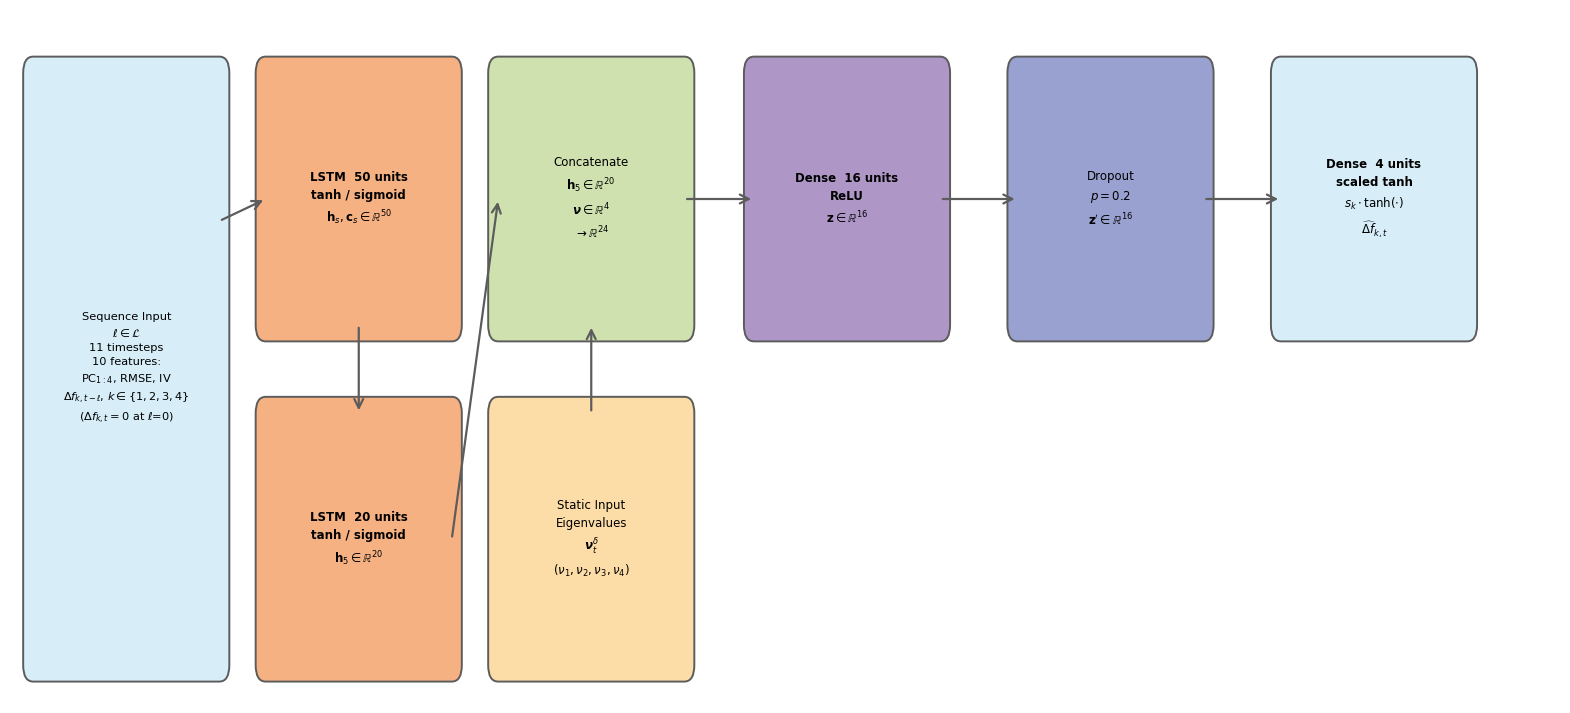

In [20]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

ECB_BLUE   = '#003899'
ECB_YELLOW = '#FFB400'
ECB_ORANGE = '#FF4B00'
ECB_GREY   = '#5C5C5C'

COL_SEQ    = '#D7EEF8'
COL_STATIC = '#FDDDA7'
COL_LSTM   = '#F6B183'
COL_CONCAT = '#CEE1AF'
COL_DENSE  = '#AE97C7'
COL_DROP   = '#98A1D0'
COL_OUT    = '#D7EEF8'

fig, ax = plt.subplots(figsize=(20, 9))
ax.set_xlim(0, 20)
ax.set_ylim(2.5, 8)
ax.axis('off')

def box(ax, x, y, w, h, text, color, fs=9, fw='normal'):
    p = FancyBboxPatch((x, y), w, h,
                       boxstyle="round,pad=0.13",
                       edgecolor=ECB_GREY, facecolor=color, linewidth=1.4)
    ax.add_patch(p)
    ax.text(x + w/2, y + h/2, text,
            ha='center', va='center', fontsize=fs,
            fontweight=fw, color='black', multialignment='center',
            linespacing=1.5)

def arrow(ax, x1, y1, x2, y2, color=ECB_GREY, lw=1.6):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=color,
                                lw=lw, mutation_scale=16))

# Box dimensions: width and height
BW   = 2.4         # box width (uniform)
BH   = 2.0         # box height = 2/3 of previous 3.0
GAP  = 0.7         # air gap between upper and lower rows

# Upper row y-bottom
TOP_Y  = 5.5
# Lower row y-bottom
BOT_Y  = TOP_Y - BH - GAP

# x positions (left edge of each column)
X_SEQ   = 0.3
X_L1    = 3.3
X_CONC  = 6.3
X_D16   = 9.6
X_DROP  = 13.0
X_OUT   = 16.4

def mid(x, y, w, h):
    return x + w/2, y + h/2

# ── Sequence input (spans both rows vertically) ───────────────────────────────
full_h = BH * 2 + GAP
box(ax, X_SEQ, BOT_Y, BW, full_h,
    'Sequence Input\n'
    '$\\ell \\in \\mathcal{L}$\n'
    '11 timesteps\n'
    '10 features:\n'
    'PC$_{1:4}$, RMSE, IV\n'
    '$\\Delta f_{k,t-\\ell}$, $k\\in\\{1,2,3,4\\}$\n'
    '($\\Delta f_{k,t}=0$ at $\\ell$=0)',
    COL_SEQ, fs=8.2)

# ── LSTM 50 (top row) ─────────────────────────────────────────────────────────
box(ax, X_L1, TOP_Y, BW, BH,
    'LSTM  50 units\ntanh / sigmoid\n'
    '$\\mathbf{h}_s, \\mathbf{c}_s \\in \\mathbb{R}^{50}$',
    COL_LSTM, fs=8.5, fw='bold')

arrow(ax, X_SEQ + BW, BOT_Y + full_h * 0.75,
          X_L1,        TOP_Y + BH/2)

# ── LSTM 20 (bottom row) ─────────────────────────────────────────────────────
box(ax, X_L1, BOT_Y, BW, BH,
    'LSTM  20 units\ntanh / sigmoid\n'
    '$\\mathbf{h}_5 \\in \\mathbb{R}^{20}$',
    COL_LSTM, fs=8.5, fw='bold')

arrow(ax, X_L1 + BW/2, TOP_Y,
          X_L1 + BW/2, BOT_Y + BH)

# ── Concatenate (top row) ────────────────────────────────────────────────────
box(ax, X_CONC, TOP_Y, BW, BH,
    'Concatenate\n'
    '$\\mathbf{h}_5 \\in \\mathbb{R}^{20}$\n'
    '$\\boldsymbol{\\nu} \\in \\mathbb{R}^{4}$\n'
    '$\\rightarrow \\mathbb{R}^{24}$',
    COL_CONCAT, fs=8.5)

arrow(ax, X_L1 + BW,      BOT_Y + BH/2,
          X_CONC,           TOP_Y + BH/2)

# ── Static input (bottom row, under concat) ───────────────────────────────────
box(ax, X_CONC, BOT_Y, BW, BH,
    'Static Input\n'
    'Eigenvalues\n'
    '$\\boldsymbol{\\nu}^{\\delta}_t$\n'
    '$(\\nu_1, \\nu_2, \\nu_3, \\nu_4)$',
    COL_STATIC, fs=8.5)

arrow(ax, X_CONC + BW/2, BOT_Y + BH,
          X_CONC + BW/2, TOP_Y)

# ── Dense 16 (top row) ───────────────────────────────────────────────────────
box(ax, X_D16, TOP_Y, BW, BH,
    'Dense  16 units\nReLU\n$\\mathbf{z} \\in \\mathbb{R}^{16}$',
    COL_DENSE, fs=8.5, fw='bold')

arrow(ax, X_CONC + BW, TOP_Y + BH/2,
          X_D16,        TOP_Y + BH/2)

# ── Dropout (top row) ────────────────────────────────────────────────────────
box(ax, X_DROP, TOP_Y, BW, BH,
    'Dropout\n$p = 0.2$\n$\\mathbf{z}^{\\prime} \\in \\mathbb{R}^{16}$',
    COL_DROP, fs=8.5)

arrow(ax, X_D16 + BW, TOP_Y + BH/2,
          X_DROP,      TOP_Y + BH/2)

# ── Dense 4 output (top row) ─────────────────────────────────────────────────
box(ax, X_OUT, TOP_Y, BW, BH,
    'Dense  4 units\nscaled tanh\n'
    '$s_k \\cdot \\tanh(\\cdot)$\n'
    '$\\widehat{\\Delta f}_{k,t}$',
    COL_OUT, fs=8.5, fw='bold')

arrow(ax, X_DROP + BW, TOP_Y + BH/2,
          X_OUT,        TOP_Y + BH/2)



In [22]:
dfstats_LSTM_VAR, dfdist_LSTM_VAR = analyse_lstm('LSTM_VAR_FULL_EIG_IV')

LSTM_VAR_FULL_EIG_IV: 2977 predictions
Period: 2014-07-24 → 2026-03-13

\begin{table}[htbp]
\centering
\caption{OOS Rolling LSTM Performance --- LSTM_VAR_FULL_EIG_IV}
\label{tab:lstm_var_full_eig_iv_performance}
\begin{tabular}{lrrrrrrr}
\hline\hline
PC & $N$ & Accuracy & $R^2$ & RMSE & AIC & BIC \\
\hline
PC1 & 2977 & 71.08% & 0.3178 & 0.008946 & -19552.15 & -19306.21 \\
PC2 & 2977 & 67.48% & 0.2252 & 0.002469 & -27216.10 & -26970.15 \\
PC3 & 2977 & 65.40% & 0.1980 & 0.001076 & -32160.95 & -31915.01 \\
PC4 & 2977 & 60.36% & 0.0026 & 0.000516 & -36541.64 & -36295.70 \\
\hline\hline
\end{tabular}
\end{table}

\begin{table}[htbp]
\centering
\caption{OOS Forecast Residual Statistics --- LSTM_VAR_FULL_EIG_IV}
\label{tab:lstm_var_full_eig_iv_residuals}
\begin{tabular}{lrrrrrr}
\hline\hline
PC & Mean & Std.\ Dev. & Min & Q25 & Q75 & Max \\
\hline
PC1 & 0.000724 & 0.008916 & -0.039789 & -0.004009 & 0.005224 & 0.048186 \\
PC2 & -0.000008 & 0.002469 & -0.012722 & -0.001214 & 0.001181 & 0.012318